# Exploratory Data Analysis

Initial look at `fraudTrain.csv` ahead of feature engineering and modelling.

## 1. Setup

In [1]:
cd ../

/Users/ann/Documents/Zempler/fraud_datasets


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.config as config

pd.options.display.max_columns = 30

## 2. Load data

In [3]:
df_train = pd.read_csv(config.TRAIN_RAW_PATH, index_col=0)

## 3. First look

In [4]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df_train.shape

(1296675, 22)

In [6]:
df_train.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [7]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01
is_fraud,1296675.0,5.788652e-03,7.586269e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [8]:
df_train.nunique()

trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

Average number of transactions per card in the sample:

In [9]:
df_train.groupby("cc_num")["cc_num"].agg(["count"]).mean()

count    1319.099695
dtype: float64

## 4. Data quality checks

In [10]:
df_train.duplicated(subset=["trans_num"]).sum()

0

In [11]:
df_train.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## 5. Class balance

In [12]:
df_train.is_fraud.value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [13]:
df_train_fraud = df_train[df_train["is_fraud"] == 1].copy()
df_train_not_fraud = df_train[df_train["is_fraud"] == 0].copy()

## 6. Time-based features and fraud rate patterns

In [14]:
df_train["trans_time"] = pd.to_datetime(df_train["trans_date_trans_time"])
df_train["trans_ym"] = pd.to_datetime(df_train["trans_date_trans_time"].str[:7])
df_train["trans_hour"] = df_train["trans_time"].dt.hour
df_train["trans_date_trans_month"] = df_train["trans_time"].dt.month

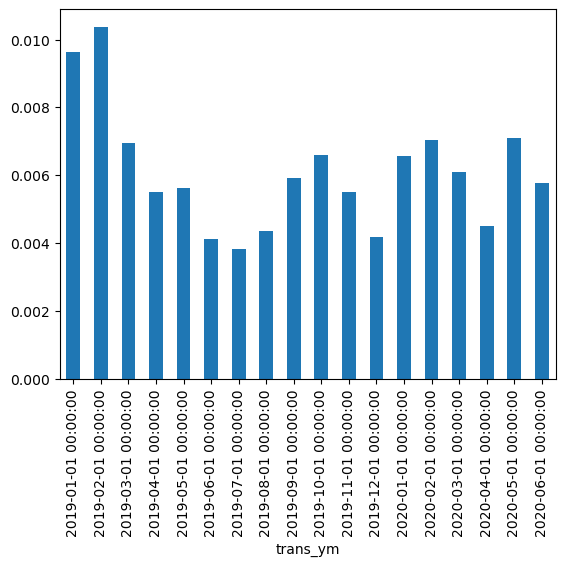

In [15]:
df_train.groupby("trans_ym")["is_fraud"].mean().plot(kind="bar")
plt.show()

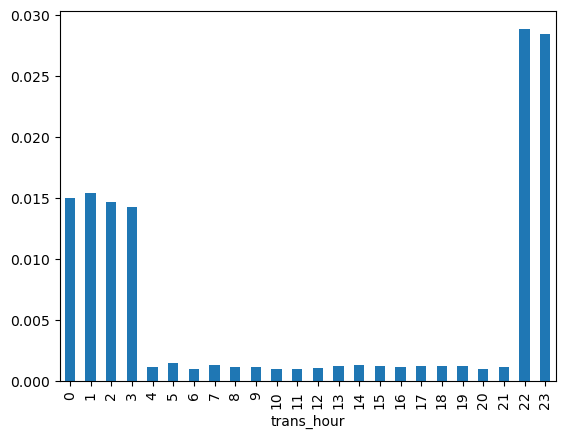

In [16]:
df_train.groupby("trans_hour")["is_fraud"].mean().plot(kind="bar")
plt.show()

**Idea:** "late night" flag could be a useful engineered feature (maybe two, one v high risk time, one high risk time).

## 7. Fraud transaction amount distribution

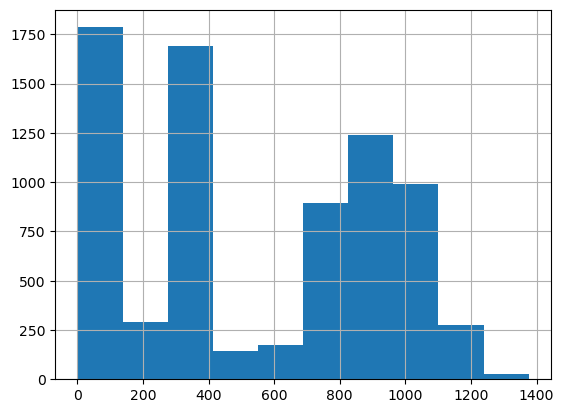

In [17]:
df_train_fraud.amt.hist()
plt.show()

## 8. Fraud rate across other segments

Checking fraud rate against customer/merchant fields not yet looked at: distance between customer and merchant, customer age, city population, state, gender, and merchant category.

### 8.1 Distance between customer and merchant

Dataset has customer `lat`/`long` and merchant `merch_lat`/`merch_long`. Calculatin distance in km, then bucketed to check for a monotonic relationship with fraud rate.

In [18]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

df_train["cust_merch_dist_km"] = haversine_km(df_train["lat"], df_train["long"], df_train["merch_lat"], df_train["merch_long"])
df_train["cust_merch_dist_km"].describe()

count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
25%      5.533491e+01
50%      7.823175e+01
75%      9.850327e+01
max      1.521172e+02
Name: cust_merch_dist_km, dtype: float64

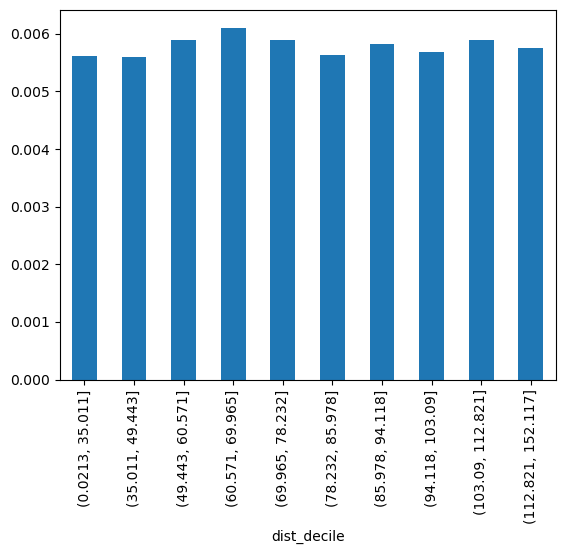

In [19]:
df_train["dist_decile"] = pd.qcut(df_train["cust_merch_dist_km"], 10, duplicates="drop")
df_train.groupby("dist_decile", observed=True)["is_fraud"].mean().plot(kind="bar")
plt.show()

Doesn't look like any relationship going on here

### 8.2 Customer age

In [20]:
df_train["age"] = ((df_train["trans_time"] - pd.to_datetime(df_train["dob"])).dt.days / 365.25).astype(int)
df_train["age"].describe()

count    1.296675e+06
mean     4.549541e+01
std      1.739698e+01
min      1.300000e+01
25%      3.200000e+01
50%      4.300000e+01
75%      5.700000e+01
max      9.500000e+01
Name: age, dtype: float64

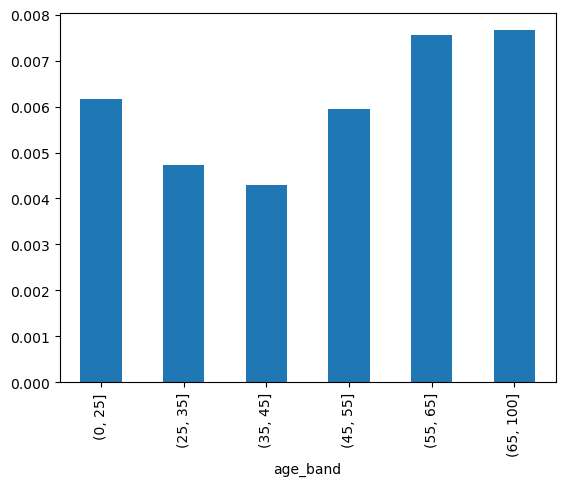

In [21]:
df_train["age_band"] = pd.cut(df_train["age"], bins=[0, 25, 35, 45, 55, 65, 100])
df_train.groupby("age_band", observed=True)["is_fraud"].mean().plot(kind="bar")
plt.show()

### 8.3 City population

Fraud rate by city size (small towns vs large cities).

In [22]:
df_train["city_pop"].describe()

count    1.296675e+06
mean     8.882444e+04
std      3.019564e+05
min      2.300000e+01
25%      7.430000e+02
50%      2.456000e+03
75%      2.032800e+04
max      2.906700e+06
Name: city_pop, dtype: float64

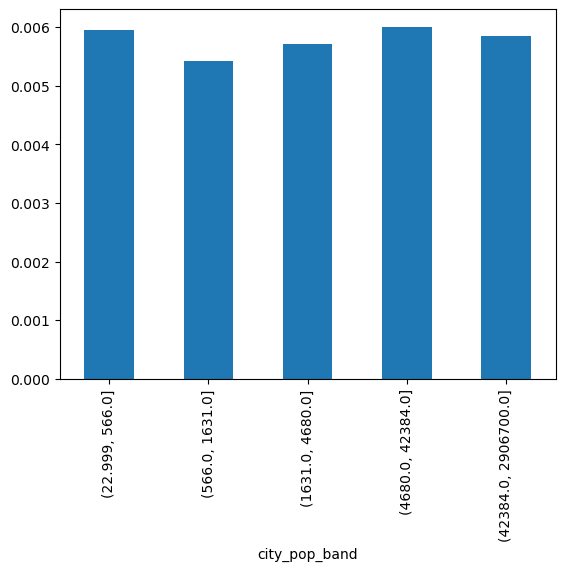

In [23]:
df_train["city_pop_band"] = pd.qcut(df_train["city_pop"], 5, duplicates="drop")
df_train.groupby("city_pop_band", observed=True)["is_fraud"].mean().plot(kind="bar")
plt.show()

### 8.4 State

Fraud rate by customer state

In [24]:
state_summary = df_train.groupby("state")["is_fraud"].agg(["mean", "count"]).sort_values("mean", ascending=False)
state_summary.head(10)

,mean,count
state,,
DE,1.000000,9
RI,0.027273,550
AK,0.016981,2120
NV,0.008382,5607
CO,0.008141,13880
OR,0.008012,18597
TN,0.007975,17554
NE,0.007448,24168
ME,0.007210,16505


In [25]:
state_summary.tail(10)

,mean,count
state,,
MO,0.004974,38403
NC,0.004923,30266
NJ,0.004796,24603
LA,0.004341,20965
ND,0.003855,14786
AZ,0.003435,10770
HI,0.002735,2559
MT,0.002722,11754
CT,0.002077,7702


In [26]:
df_train[df_train["state"] == "DE"].cc_num.unique()

array([6011826317034777])

Looks like one incident of fraud occurred in this state - volume too thin anyway

In [27]:
df_train[df_train["state"] == "RI"].groupby("merchant")["is_fraud"].agg(["mean", "count"]).sort_values("mean",ascending=False).T

merchant,"fraud_Witting, Beer and Ernser",fraud_Metz-Boehm,fraud_Cole PLC,fraud_Jacobi and Sons,"fraud_Mosciski, Gislason and Mertz",fraud_Durgan-Auer,fraud_Spencer PLC,"fraud_Heathcote, Yost and Kertzmann","fraud_Rodriguez, Yost and Jenkins","fraud_Towne, Greenholt and Koepp",fraud_Bogisich-Homenick,"fraud_Haley, Jewess and Bechtelar",fraud_Cormier LLC,"fraud_Streich, Dietrich and Barton",fraud_Nienow PLC,...,fraud_Heathcote LLC,"fraud_Hayes, Marquardt and Dibbert","fraud_Hauck, Dietrich and Funk",fraud_Harris Inc,fraud_Hammes-Beatty,"fraud_Greenholt, O'Hara and Balistreri",fraud_Hamill-Daugherty,fraud_Haley Group,"fraud_Hahn, Bahringer and McLaughlin","fraud_Hagenes, Kohler and Hoppe","fraud_Hagenes, Hermann and Stroman",fraud_Haag-Blanda,fraud_Gutmann-Upton,fraud_Gulgowski LLC,"fraud_Zieme, Bode and Dooley"
mean,1.0,1.0,1.0,1.0,1.0,0.666667,0.5,0.5,0.5,0.5,0.5,0.5,0.333333,0.333333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
count,1.0,1.0,1.0,1.0,1.0,3.000000,2.0,2.0,2.0,2.0,2.0,2.0,3.000000,3.000000,1.0,...,2.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0


In [28]:
df_train[df_train["state"] == "AK"].groupby("merchant")["is_fraud"].agg(["mean", "count"]).sort_values("mean",ascending=False).T

merchant,"fraud_Stokes, Christiansen and Sipes",fraud_Metz-Boehm,fraud_Kiehn Inc,fraud_Pouros-Haag,fraud_Wisozk and Sons,"fraud_Moore, Dibbert and Koepp",fraud_Terry-Huel,"fraud_Schumm, Bauch and Ondricka",fraud_Schmitt Ltd,fraud_Fisher-Schowalter,fraud_Friesen Ltd,fraud_Jacobi and Sons,"fraud_Altenwerth, Cartwright and Koss",fraud_McGlynn-Heathcote,fraud_Kiehn-Emmerich,...,"fraud_Hagenes, Hermann and Stroman","fraud_Hagenes, Kohler and Hoppe","fraud_Hahn, Douglas and Schowalter","fraud_Haley, Batz and Auer","fraud_Haley, Jewess and Bechtelar",fraud_Halvorson Group,fraud_Hamill-D'Amore,fraud_Hamill-Daugherty,fraud_Hammes-Beatty,fraud_Harber Inc,fraud_Harris Group,fraud_Harris Inc,"fraud_Hartmann, Rowe and Hermann","fraud_Hayes, Marquardt and Dibbert",fraud_Zulauf LLC
mean,1.0,1.0,0.5,0.5,0.5,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.25,0.25,0.25,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
count,1.0,1.0,2.0,2.0,2.0,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.00,4.00,4.00,4.00,...,2.0,1.0,1.0,3.0,3.0,5.0,3.0,3.0,3.0,6.0,2.0,2.0,5.0,1.0,3.0


Lots of noise. ignoring state

### 8.5 Gender

In [29]:
df_train.groupby("gender")["is_fraud"].agg(["mean", "count"])

,mean,count
gender,,
F,0.005262,709863
M,0.006426,586812


### 8.6 Merchant category

In [30]:
cat_summary = df_train.groupby("category")["is_fraud"].agg(["mean", "count"]).sort_values("mean", ascending=False)
cat_summary.T

category,shopping_net,misc_net,grocery_pos,shopping_pos,gas_transport,misc_pos,grocery_net,travel,entertainment,personal_care,kids_pets,food_dining,home,health_fitness
mean,0.017561,0.014458,0.014098,0.007225,0.004694,0.003139,0.002948,0.002864,0.002478,0.002424,0.002114,0.001651,0.001608,0.001549
count,97543.000000,63287.000000,123638.000000,116672.000000,131659.000000,79655.000000,45452.000000,40507.000000,94014.000000,90758.000000,113035.000000,91461.000000,123115.000000,85879.000000


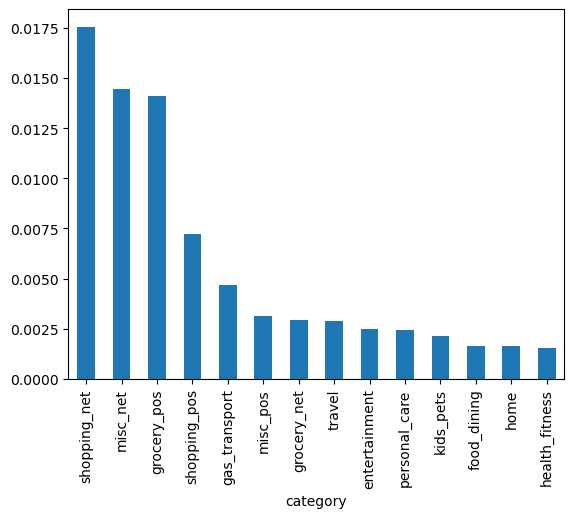

In [31]:
cat_summary["mean"].plot(kind="bar")
plt.show()

**Idea:** high risk categories flag: shopping_net, misc_net, maybe also grocery_pos - unsure why fraud rate is so high for this category

In [32]:
df_train.groupby("category")["amt"].agg(["mean"]).sort_values("mean", ascending=True).T

category,personal_care,food_dining,grocery_net,health_fitness,kids_pets,home,misc_pos,gas_transport,entertainment,shopping_pos,misc_net,shopping_net,travel,grocery_pos
mean,47.967678,51.086905,53.670084,54.18214,57.536871,58.270139,62.890999,63.434572,64.210421,79.779155,80.865095,88.424076,111.50472,116.960986


### 8.7 Transaction amount

Fraud rate across amount bands (population-level for thresholding).

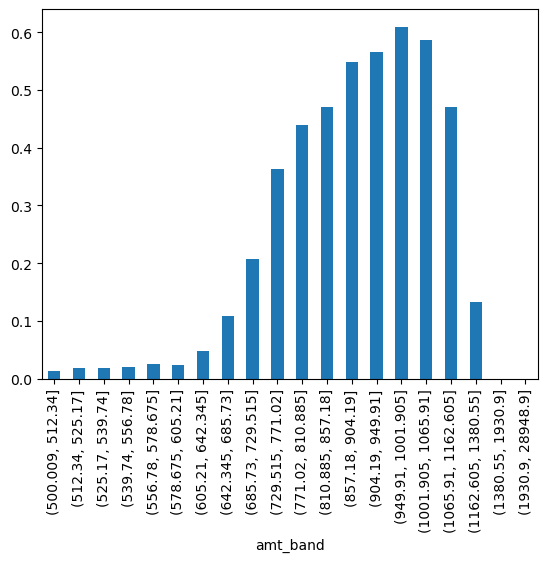

In [33]:
df_train_HV = df_train[df_train["amt"] > 500].copy()

df_train_HV["amt_band"] = pd.qcut(df_train_HV["amt"], 20, duplicates="drop")
df_train_HV.groupby("amt_band", observed=True)["is_fraud"].mean().plot(kind="bar")
plt.show()

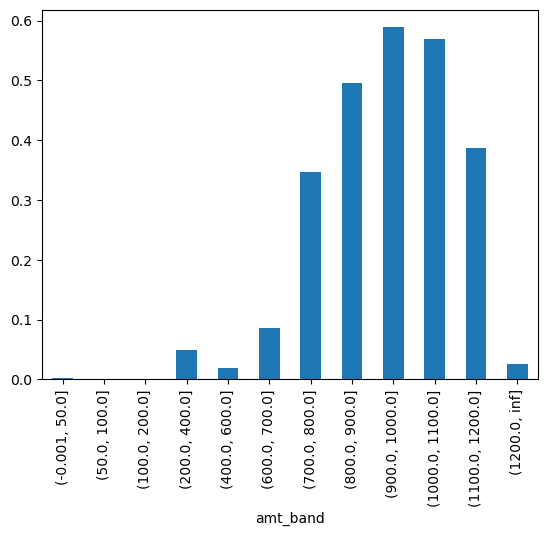

In [34]:
AMT_BIN_EDGES = [0, 50, 100, 200, 400, 600, 700, 800, 900, 1000, 1100, 1200, np.inf]

df_train["amt_band"] = pd.cut(df_train["amt"], bins=AMT_BIN_EDGES, include_lowest=True)
df_train.groupby("amt_band", observed=True)["is_fraud"].mean().plot(kind="bar")
plt.show()

In [35]:
df_train.groupby("amt_band", observed=True)["is_fraud"].agg(["sum", "count", "mean"])

,sum,count,mean
amt_band,,,
"(-0.001, 50.0]",1607,672299,0.002390
"(50.0, 100.0]",45,389483,0.000116
"(100.0, 200.0]",150,172969,0.000867
"(200.0, 400.0]",1955,40226,0.048600
"(400.0, 600.0]",195,10625,0.018353
"(600.0, 700.0]",167,1945,0.085861
"(700.0, 800.0]",663,1910,0.347120
"(800.0, 900.0]",831,1679,0.494937
"(900.0, 1000.0]",944,1603,0.588896


**Idea:** try out this binned version of amount since relationship between fraud and amount looks non-linear, with fraud rates being highest for purchases b/w £700 and £1200

## 9. Time since last transaction (customer level)

Backward-looking gap since the customer's previous transaction, sorted by time.

In [36]:
df_train = df_train.sort_values(["cc_num", "trans_time"])

df_train["prev_trans_time"] = df_train.groupby("cc_num")["trans_time"].shift(1)
df_train["time_since_last_trans"] = df_train["trans_time"] - df_train["prev_trans_time"]
df_train["time_since_last_trans_mins"] = df_train["time_since_last_trans"].dt.total_seconds() / 60
df_train["time_since_last_trans_mins"].describe()

count    1.295692e+06
mean     5.414169e+02
std      7.900163e+02
min      0.000000e+00
25%      1.002167e+02
50%      2.760000e+02
75%      6.703833e+02
max      2.235785e+04
Name: time_since_last_trans_mins, dtype: float64

In [37]:
df_train["is_first_transaction"] = df_train["time_since_last_trans"].isna().astype(int)
df_train["is_first_transaction"].value_counts()

is_first_transaction
0    1295692
1        983
Name: count, dtype: int64

In [38]:
df_train.groupby("is_first_transaction")["is_fraud"].mean()

is_first_transaction
0    0.005735
1    0.076297
Name: is_fraud, dtype: float64

Fraud rate by time-since-last-transaction band, excluding first transactions.

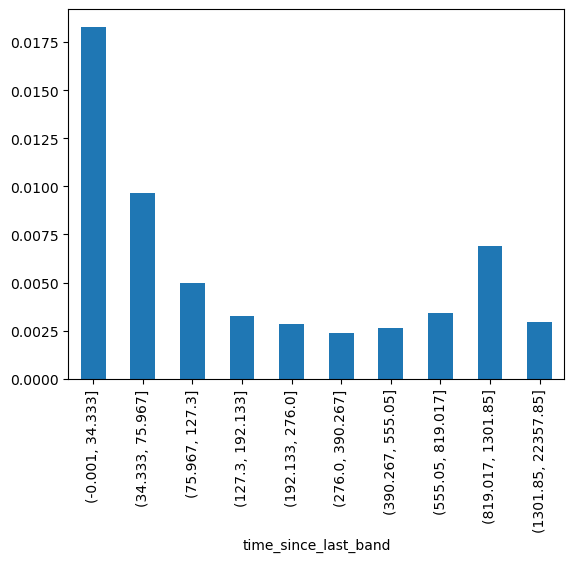

In [39]:
has_prev = df_train[df_train["is_first_transaction"] == 0].copy()
has_prev["time_since_last_band"] = pd.qcut(
    has_prev["time_since_last_trans_mins"], 10, duplicates="drop"
)
has_prev.groupby("time_since_last_band", observed=True)["is_fraud"].mean().plot(kind="bar")
plt.show()

## 10. Population definition and possible exclusions

### Population exclusions to investigate

Cold-start customers: first transaction / first N days. Determine whether these observations should be excluded or whether cold-start behaviour should be treated as part of the prediction problem.

Extreme distance/amount observations: investigate whether these represent genuine tail risk or potential simulator artefacts before considering exclusion. In a fraud model, extreme values may themselves be important fraud signals.

Missing/invalid observations: identify records with missing or implausible values and determine whether they require exclusion or explicit treatment.

All these are checked in `00B_fraud_population_screening.ipynb`, no population exclusions are being made for this data.


## 11. Open questions / feature ideas

Revisit during feature engineering:

- Deviation from a customer's usual transaction amount
- "Late night" flag based on `trans_hour`
- Different thresholds for a high-value purchase flag (see section 8.7)
- Flag of first transaction

## 12. Column decisions (keep / drop / derive)

Full column disposition now lives in `config.py` (`DROP_COLS`, `CATEGORICAL_FEATURE_COLS`, `NUMERIC_FEATURE_COLS`). Summary:

- **Keep as-is:** `category`
- **Keep, derived:** `lat`/`long`/`merch_lat`/`merch_long` → `cust_merch_dist_km`; `dob` → `age`/`age_band`; `trans_date_trans_time` → `trans_hour`/day-of-week/`time_since_last_trans`; `city_pop` → `city_pop_band`; `amt` → `amt_band`
- **Drop bc identifiers:** `trans_num`, `first`, `last`, `street`, `unix_time` (`cc_num` kept as a grouping key only)
- **Drop bc not used:** `merchant`
- **Drop bc fairness:** `gender` (0.53% vs 0.64%, small effect), `state` (noisy + location proxy)
- **Drop bc quasi-identifiers::** , `job`, `zip` (both are relatively high-cardinality features (494 and 970 unique values))

## 13. Test-set structural checks

Looking into how `fraudTrain.csv` and `fraudTest.csv` relate, needed for the carry-forward join in section 9. Uses only identifiers and timestamps(no `is_fraud`) so it doesn't leak test-set labels

In [40]:
df_test = pd.read_csv(config.TEST_RAW_PATH, index_col=0)
print(f"Test: {df_test.shape[0]:,} rows ({df_test['trans_date_trans_time'].min()} → {df_test['trans_date_trans_time'].max()}), fraud rate {df_test['is_fraud'].mean()}")

Test: 555,719 rows (2020-06-21 12:14:25 → 2020-12-31 23:59:34), fraud rate 0.0038598644278853163


**Customer overlap:** how many test-set customers are genuinely new (never appear in train) versus returning accounts continuing later in time.

In [41]:
test_cc_num = set(df_test["cc_num"].tolist())
train_cc_num = set(df_train["cc_num"].tolist())

new_in_test = [x for x in test_cc_num if x not in train_cc_num]
len(new_in_test)

16

**Time continuity:** checking whether test picks up right where train leaves off, or whether there's a gap between the two files.

In [42]:
df_train["trans_date_trans_time"].max(), df_test["trans_date_trans_time"].min()

('2020-06-21 12:13:37', '2020-06-21 12:14:25')

Only 16 test customers are genuinely new (~984 are returning), and train ends ~1min before test starts; effectively one continuous stream. Carry-forward join is needed for `time_since_last_trans`